## Lendo o arquivo de distancias

In [11]:
import json
import pandas as pd

distances_file_name = "distances_1_3_raw.json"

In [12]:
with open(distances_file_name, "r") as f:
    distances = json.load(f)

## Calculando a média de cada distância

In [13]:
distances_df = pd.DataFrame(distances)
distances_df.head()

,file_name,fft_distance,stft_distance,log_mel_spectrogram_distance_raw,log_mel_spectrogram_distance_normalized,log_mel_num_elements
0,keyboard_electronic_001-040-075.wav,13134.049805,2476.599121,165.471085,0.010260,16128
1,keyboard_synthetic_000-047-050.wav,8929.506836,1796.481689,94.702835,0.005872,16128
2,vocal_acoustic_000-060-050.wav,15956.996094,3189.194092,213.585434,0.013243,16128
3,brass_acoustic_006-042-075.wav,15581.250000,2811.974121,234.898621,0.014565,16128
4,keyboard_electronic_078-044-100.wav,14332.041016,2604.873291,210.415802,0.013047,16128


In [14]:
# Médias e desvios das métricas
mean_fft = distances_df['fft_distance'].mean()
std_fft = distances_df['fft_distance'].std()

mean_stft = distances_df['stft_distance'].mean()
std_stft = distances_df['stft_distance'].std()

mean_logmel_raw = distances_df['log_mel_spectrogram_distance_raw'].mean()
std_logmel_raw = distances_df['log_mel_spectrogram_distance_raw'].std()

mean_logmel_norm = distances_df['log_mel_spectrogram_distance_normalized'].mean()
std_logmel_norm = distances_df['log_mel_spectrogram_distance_normalized'].std()

print(f"Média FFT: {mean_fft}")
print(f"Desvio padrão FFT: {std_fft}")
print(f"Média STFT: {mean_stft}")
print(f"Desvio padrão STFT: {std_stft}")
print(f"Média Log Mel (raw): {mean_logmel_raw}")
print(f"Desvio padrão Log Mel (raw): {std_logmel_raw}")
print(f"Média Log Mel (normalizado): {mean_logmel_norm}")
print(f"Desvio padrão Log Mel (normalizado): {std_logmel_norm}")

Média FFT: 14975.80833375454
Desvio padrão FFT: 6224.329767238834
Média STFT: 2890.8717213720083
Desvio padrão STFT: 1123.7703343597548
Média Log Mel (raw): 162.1246553887613
Desvio padrão Log Mel (raw): 60.58567129316845
Média Log Mel (normalizado): 0.010052371984954789
Desvio padrão Log Mel (normalizado): 0.0037565520343052546


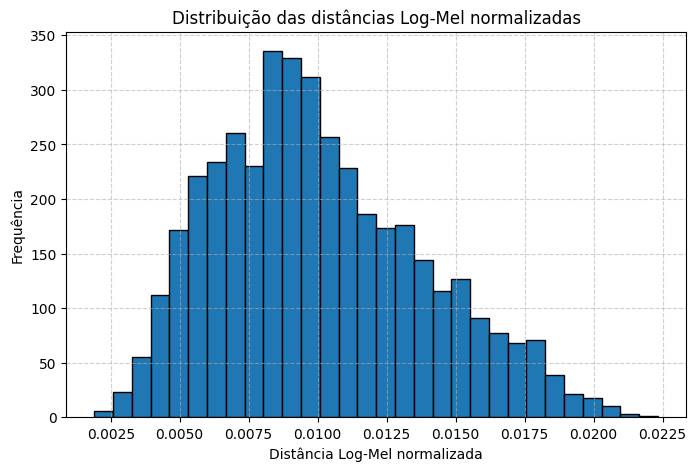

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# carregar o JSON salvo
distances_df = pd.read_json(distances_file_name)

# histograma da métrica log-mel normalizada
plt.figure(figsize=(8, 5))
plt.hist(
    distances_df["log_mel_spectrogram_distance_normalized"],
    bins=30,
    edgecolor="black"
)
plt.title("Distribuição das distâncias Log-Mel normalizadas")
plt.xlabel("Distância Log-Mel normalizada")
plt.ylabel("Frequência")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


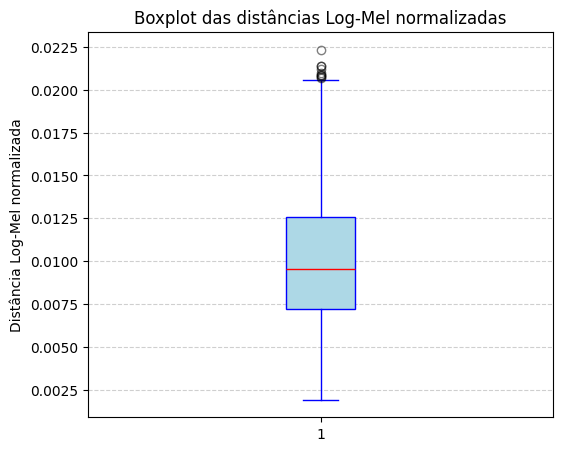

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# carregar o JSON salvo
distances_df = pd.read_json(distances_file_name)

# boxplot da métrica log-mel normalizada
plt.figure(figsize=(6, 5))
plt.boxplot(
    distances_df["log_mel_spectrogram_distance_normalized"],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red"),
    whiskerprops=dict(color="blue"),
    capprops=dict(color="blue"),
    flierprops=dict(marker="o", color="gray", alpha=0.5),
)
plt.title("Boxplot das distâncias Log-Mel normalizadas")
plt.ylabel("Distância Log-Mel normalizada")
plt.grid(True, linestyle="--", alpha=0.6, axis="y")
plt.show()


In [17]:
import pandas as pd

# carregar JSON salvo
distances_df = pd.read_json(distances_file_name)

# estatísticas descritivas para a métrica log-mel normalizada
summary_stats = {
    "mean": distances_df["log_mel_spectrogram_distance_normalized"].mean(),
    "std": distances_df["log_mel_spectrogram_distance_normalized"].std(),
    "min": distances_df["log_mel_spectrogram_distance_normalized"].min(),
    "p25": distances_df["log_mel_spectrogram_distance_normalized"].quantile(0.25),
    "median": distances_df["log_mel_spectrogram_distance_normalized"].median(),
    "p75": distances_df["log_mel_spectrogram_distance_normalized"].quantile(0.75),
    "p90": distances_df["log_mel_spectrogram_distance_normalized"].quantile(0.90),
    "p95": distances_df["log_mel_spectrogram_distance_normalized"].quantile(0.95),
    "max": distances_df["log_mel_spectrogram_distance_normalized"].max(),
}

summary_df = pd.DataFrame(summary_stats, index=["log_mel_norm"])
print(summary_df.T)


        log_mel_norm
mean        0.010052
std         0.003757
min         0.001907
p25         0.007212
median      0.009530
p75         0.012580
p90         0.015455
p95         0.017144
max         0.022335


## Calculate grouped metrics

In [18]:
import pandas as pd

# criar coluna de grupo pela primeira palavra do file_name
distances_df["group"] = distances_df["file_name"].str.split("_").str[0]

# calcular estatísticas por grupo
group_stats = distances_df.groupby("group").agg(
    mean_fft=("fft_distance", "mean"),
    mean_stft=("stft_distance", "mean"),
    mean_logmel_raw=("log_mel_spectrogram_distance_raw", "mean"),
    mean_logmel_norm=("log_mel_spectrogram_distance_normalized", "mean"),
    std_fft=("fft_distance", "std"),
    std_stft=("stft_distance", "std"),
    std_logmel_raw=("log_mel_spectrogram_distance_raw", "std"),
    std_logmel_norm=("log_mel_spectrogram_distance_normalized", "std"),
)

print(group_stats)

              mean_fft    mean_stft  mean_logmel_raw  mean_logmel_norm  \
group                                                                    
bass      13303.403053  2609.173479       145.412401          0.009016   
brass     15997.690030  3009.734972       205.092932          0.012717   
flute     17228.889518  3510.259174       172.040978          0.010667   
guitar    12414.097074  2441.170738       138.348840          0.008578   
keyboard  11626.983219  2265.704295       133.651869          0.008287   
mallet    10113.676219  2064.883391       120.336226          0.007461   
organ     21845.767975  4211.060801       221.808123          0.013753   
reed      15672.487691  2976.537337       185.217070          0.011484   
string    15729.950175  2960.370609       169.725136          0.010524   
vocal     29896.209296  5222.840498       224.427564          0.013915   

              std_fft     std_stft  std_logmel_raw  std_logmel_norm  
group                                    